In [44]:
import pandas as pd
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [45]:
df["development_status"] = pd.qcut(df["gdpp"],q=3,labels=["Low", "Medium", "High"])

In [46]:
from sklearn.preprocessing import LabelEncoder
X = df.drop(["country","gdpp","development_status"], axis=1)
y = df["development_status"]
le = LabelEncoder()
y = le.fit_transform(y)

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8529411764705882


In [49]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [50]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100,max_depth=4,learning_rate=0.1,random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.8529411764705882


In [51]:
print("Random Forest :", rf_acc)
print("XGBoost :", xgb_acc)

Random Forest : 0.8529411764705882
XGBoost : 0.8529411764705882


In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(["country","development_status"], axis=1))

In [53]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,random_state=42)
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)
print(df[["country","KMeans_Cluster"]].head())

               country  KMeans_Cluster
0          Afghanistan               2
1              Albania               0
2              Algeria               0
3               Angola               2
4  Antigua and Barbuda               0


C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df["income"],df["gdpp"],c=df["KMeans_Cluster"])
plt.xlabel("Income")
plt.ylabel("GDP")
plt.title("Country Segmentation using K-Means")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.5,min_samples=5)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)
print(df["DBSCAN_Cluster"].value_counts())

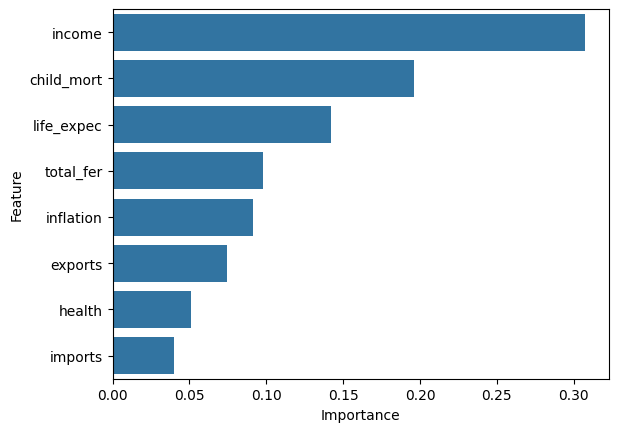

In [43]:
import seaborn as sns
importance = rf.feature_importances_
feat_imp = pd.DataFrame({"Feature": X.columns,"Importance": importance})
feat_imp = feat_imp.sort_values(by="Importance",ascending=False)
sns.barplot(x="Importance",y="Feature",data=feat_imp)
plt.show()